#### Importing Libraries

In [3]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
# Modelling
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRFRegressor
import warnings
warnings.filterwarnings('ignore')

#### Import the CSV Data as Pandas Dataframe

In [4]:
df = pd.read_csv('data/StudentsPerformance.csv')
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


#### Preparing the Dependent and Indpendent Variables

In [7]:
X = df.drop(columns=['math score'], axis = 1)
X.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [9]:
y = df['math score']
y.head()

0    72
1    69
2    90
3    47
4    76
Name: math score, dtype: int64

In [10]:
print("Categories in 'Gender' variable:     ", end=' ')
print(df['gender'].unique())

print("Categories in 'Race/Ethnicity' variable:     ", end=' ')
print(df['race/ethnicity'].unique())

print("Categories in 'Parental level of Education' variable:     ", end=' ')
print(df['parental level of education'].unique())

print("Categories in 'Lunch' variable:     ", end=' ')
print(df['lunch'].unique())

print("Categories in 'Test Preparation Course' variable:     ", end=' ')
print(df['test preparation course'].unique())

Categories in 'Gender' variable:      ['female' 'male']
Categories in 'Race/Ethnicity' variable:      ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in 'Parental level of Education' variable:      ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in 'Lunch' variable:      ['standard' 'free/reduced']
Categories in 'Test Preparation Course' variable:      ['none' 'completed']


#### Create Column Transformer with 3 types of Transformer

In [11]:
num_features = X.select_dtypes(exclude='object').columns
cat_features = X.select_dtypes(include='object').columns
num_features, cat_features

(Index(['reading score', 'writing score'], dtype='object'),
 Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
        'test preparation course'],
       dtype='object'))

In [12]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        (
            "OneHotEncoder", oh_transformer, cat_features
        ),
        (
            "StandardSclaer", numeric_transformer, num_features
        )
    ]
)
preprocessor

ColumnTransformer(transformers=[('OneHotEncoder', OneHotEncoder(),
                                 Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course'],
      dtype='object')),
                                ('StandardSclaer', StandardScaler(),
                                 Index(['reading score', 'writing score'], dtype='object'))])

In [13]:
X = preprocessor.fit_transform(X)
X

array([[ 1.        ,  0.        ,  0.        , ...,  1.        ,
         0.19399858,  0.39149181],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         1.42747598,  1.31326868],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.77010859,  1.64247471],
       ...,
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.12547206, -0.20107904],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.60515772,  0.58901542],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.15336989,  1.18158627]])

#### Separation of Data into Train and Test

In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((800, 19), (200, 19))

#### Create an Evaluate Function to give all Metrics after Model Training

In [18]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mse)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square


In [22]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRFRegressor(),
    "Cat Boostting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}

model_list = []
r2_list = []

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train)  # Train Model

    # Make Prediction
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Evaluate Train and Test Dataset
    model_train_mae, model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)
    model_test_mae, model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print('Model Performance for Training Set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- Root Mean Squared Error: {:.4f}".format(model_train_r2))

    print('==='*8)

    print('Model Performance for Test Set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- Root Mean Squared Error: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)

    print("=>="*12)
    print('\n\n')

Linear Regression
Model Performance for Training Set
- Root Mean Squared Error: 5.3272
- Mean Absolute Error: 4.2784
- Root Mean Squared Error: 0.8741
Model Performance for Test Set
- Root Mean Squared Error: 5.4108
- Mean Absolute Error: 4.2279
- Root Mean Squared Error: 0.8797
=>==>==>==>==>==>==>==>==>==>==>==>=



Lasso
Model Performance for Training Set
- Root Mean Squared Error: 6.5938
- Mean Absolute Error: 5.2063
- Root Mean Squared Error: 0.8071
Model Performance for Test Set
- Root Mean Squared Error: 6.5197
- Mean Absolute Error: 5.1579
- Root Mean Squared Error: 0.8253
=>==>==>==>==>==>==>==>==>==>==>==>=



Ridge
Model Performance for Training Set
- Root Mean Squared Error: 5.3233
- Mean Absolute Error: 4.2650
- Root Mean Squared Error: 0.8743
Model Performance for Test Set
- Root Mean Squared Error: 5.3904
- Mean Absolute Error: 4.2111
- Root Mean Squared Error: 0.8806
=>==>==>==>==>==>==>==>==>==>==>==>=



K-Neighbors Regressor
Model Performance for Training Set
- Root 

  File "d:\Code\AI-Bootcamp\Projects\2_predictor\venv\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "d:\Code\AI-Bootcamp\Projects\2_predictor\venv\lib\subprocess.py", line 489, in run
    with Popen(*popenargs, **kwargs) as process:
  File "d:\Code\AI-Bootcamp\Projects\2_predictor\venv\lib\subprocess.py", line 854, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "d:\Code\AI-Bootcamp\Projects\2_predictor\venv\lib\subprocess.py", line 1307, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,


Random Forest Regressor
Model Performance for Training Set
- Root Mean Squared Error: 2.2567
- Mean Absolute Error: 1.7997
- Root Mean Squared Error: 0.9774
Model Performance for Test Set
- Root Mean Squared Error: 6.0713
- Mean Absolute Error: 4.6968
- Root Mean Squared Error: 0.8485
=>==>==>==>==>==>==>==>==>==>==>==>=



XGBRegressor
Model Performance for Training Set
- Root Mean Squared Error: 4.7225
- Mean Absolute Error: 3.7879
- Root Mean Squared Error: 0.9011
Model Performance for Test Set
- Root Mean Squared Error: 5.7858
- Mean Absolute Error: 4.5153
- Root Mean Squared Error: 0.8624
=>==>==>==>==>==>==>==>==>==>==>==>=



Cat Boostting Regressor
Model Performance for Training Set
- Root Mean Squared Error: 3.0427
- Mean Absolute Error: 2.4054
- Root Mean Squared Error: 0.9589
Model Performance for Test Set
- Root Mean Squared Error: 6.0086
- Mean Absolute Error: 4.6125
- Root Mean Squared Error: 0.8516
=>==>==>==>==>==>==>==>==>==>==>==>=



AdaBoost Regressor
Model Performa

### Results

In [26]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model Name', 'R2_Score'])

,Model Name,R2_Score
0,Linear Regression,0.879689
1,Lasso,0.825320
2,Ridge,0.880593
3,K-Neighbors Regressor,0.783898
4,Decision Tree,0.749279
5,Random Forest Regressor,0.848522
6,XGBRegressor,0.862432
7,Cat Boostting Regressor,0.851632
8,AdaBoost Regressor,0.849654


### Linear Regression

In [30]:
# We chose Linear Regression over Lasso because there isn't much difference between both
lin_model = LinearRegression(fit_intercept=True)
lin_model = lin_model.fit(X_train, y_train)
y_pred = lin_model.predict(X_test)
score = r2_score(y_test, y_pred)*100
print("Accuracy of the Model is %.2f" %score)

Accuracy of the Model is 87.97


### Important Plots

Text(0, 0.5, 'Predicted')

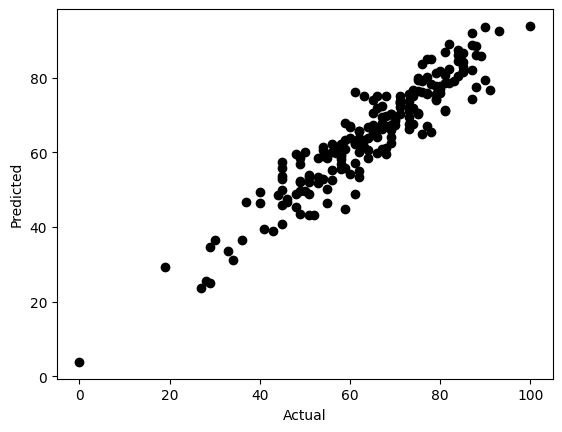

In [35]:
plt.scatter(y_test, y_pred, color='black')
plt.xlabel('Actual')
plt.ylabel('Predicted')

<Axes: xlabel='math score'>

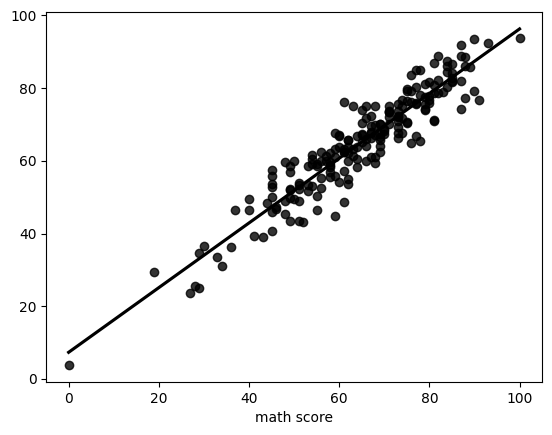

In [34]:
sns.regplot(x=y_test, y=y_pred, ci=None, color='black')

### Difference between Actual and Predicted values

In [36]:
pred_df = pd.DataFrame({'Actual Value':y_test, 'Predicted Value':y_pred, 'Difference': y_test-y_pred})
pred_df

,Actual Value,Predicted Value,Difference
521,91,76.734375,14.265625
737,53,58.593750,-5.593750
740,80,76.843750,3.156250
660,74,76.750000,-2.750000
411,84,87.500000,-3.500000
...,...,...,...
408,52,43.156250,8.843750
332,62,62.125000,-0.125000
208,74,67.578125,6.421875
613,65,67.343750,-2.343750
